In [35]:
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
import inception.instruments.auto_callable_note_v2 as note_v2
from inception.instruments.constant_parameters import NOTES_PARAMETERS

import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

In [36]:
corr = np.array(
    [[1., 0.96432854, 0.80799003],
     [0.96432854, 1., 0.8267037],
     [0.80799003, 0.8267037, 1.]]
)
issued_price = [382.82, 494.08, 142.86]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
parameters = NOTES_PARAMETERS['Multi Assets One Year']

In [37]:
evaluate_date = '2024-08-09'
path_num = 100_000

stock_price = [382.82, 494.08, 142.86]
p_range = np.arange(0.8, 1.2, 0.01)


delta_list = []
gamma_list = []
value_list = []

for p in tqdm(p_range):
    stock_price[0] = issued_price[0] * p
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, stock_price, risk_free_rate, index_vol, corr, seed=None)
    notes = MultiAssetAutoCallableNote(evaluate_date,
                                   ['A', 'B', 'C'],
                                   simulator,
                                   parameters['valuation dates'],
                                   parameters['coupon dates'],
                                   parameters['call dates'],
                                   coupon_barrier=parameters['coupon barrier'],
                                   call_barrier=parameters['call barrier'],
                                   principal_barrier=parameters['principal barrier'],
                                   coupon_amount=parameters['coupon amount'],
                                   free_rate=risk_free_rate,
                                   n_paths=path_num)

    value_list.append(notes.value)
    delta_list.append(notes.delta)
    gamma_list.append(notes.gamma)


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [01:37<00:00,  2.43s/it]


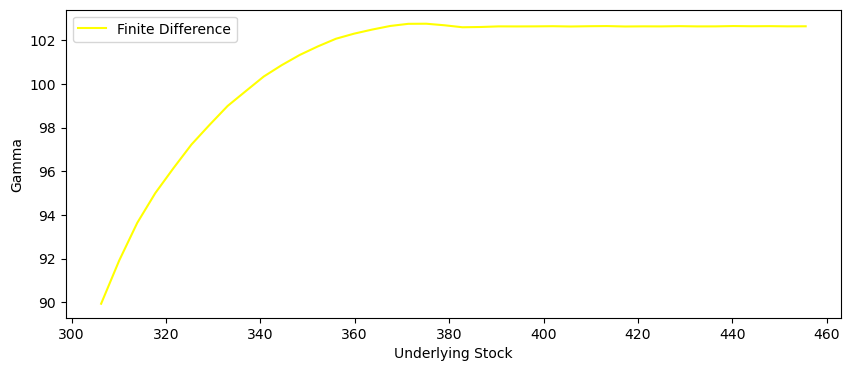

In [43]:
plt.figure(figsize=[10, 4])
plt.plot([issued_price[0] * p for p in p_range], [d for d in value_list], color='yellow', label='Finite Difference')

plt.ylabel('Gamma')
plt.xlabel('Underlying Stock')
plt.legend()

Auto Call probability: 0.64657


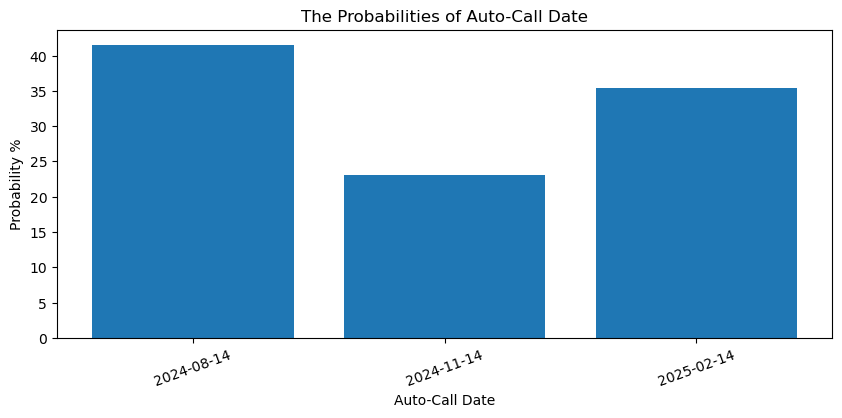

In [44]:
from collections import Counter
print(f'Auto Call probability: {notes.call_ratio}')
notes.termination_date_list.sort()
date_count = Counter(notes.termination_date_list)

y = [n / (path_num * 2) * 100 for n in date_count.values()]
plt.figure(figsize=(10, 4))
plt.bar(range(len(date_count)), y)
_ = plt.xticks(range(len(date_count)), date_count.keys(), rotation  =20)
plt.title('The Probabilities of Auto-Call Date')
_ = plt.ylabel('Probability %')
_ = plt.xlabel('Auto-Call Date')